In [19]:
#celda 1

import pandas as pd
import matplotlib.pyplot as plt
import nltk

In [20]:
#celda 2
total_df = pd.read_csv('df_total.csv')
total_df.info()

print()
cantidad_documentos = total_df.shape[0]

print(f"El corpus tiene {cantidad_documentos} documentos.")
print("Columnas del corpus:", total_df.columns.tolist())
total_df.head()



<class 'pandas.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     1217 non-null   str  
 1   news    1217 non-null   str  
 2   Type    1217 non-null   str  
dtypes: str(3)
memory usage: 28.7 KB

El corpus tiene 1217 documentos.
Columnas del corpus: ['url', 'news', 'Type']


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


**¿Cuántos documentos tiene el corpus?**

El corpus tiene 1217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?**

url: enlace a la noticia original.

news: texto completo de la noticia.

Type: categoría/etiqueta asignada a la noticia.

In [21]:
#celda 3
print("Cantidad de categorías:", total_df['Type'].nunique())
print()
print("Distribución:")
print(total_df['Type'].value_counts())
print()
print("Distribución (%):")
print((total_df['Type'].value_counts(normalize=True) * 100).round(2))

Cantidad de categorías: 7

Distribución:
Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

Distribución (%):
Type
Macroeconomia     27.94
Alianzas          20.30
Innovacion        16.02
Regulaciones      11.67
Sostenibilidad    11.26
Otra              10.68
Reputacion         2.14
Name: proportion, dtype: float64


In [22]:
#celda 4
print("Filas totalmente duplicadas:", total_df.duplicated().sum())
print("News (texto) duplicado:", total_df.duplicated(subset='news').sum())
print()
print("Valores nulos por columna:")
print(total_df.isnull().sum())
print()
print("Filas con texto vacío en news:", (total_df['news'].str.strip() == '').sum())

Filas totalmente duplicadas: 75
News (texto) duplicado: 79

Valores nulos por columna:
url     0
news    0
Type    0
dtype: int64

Filas con texto vacío en news: 4


**¿Cuántas categorías hay y cómo se distribuyen?**

El corpus tiene 7 categorías: Macroeconomia, Alianzas, 
Innovación, Regulaciones, Sostenibilidad, Otra y Reputación. No están nada balanceadas, solo macroeconomía tiene 
casi 3 veces más noticias que Regulaciones o Sostenibilidad, y Reputacion es casi indiferente, ya que es bastante pequeña comparada con las demás.

**¿Hay filas vacías o duplicadas?**

Sí, hay 75 filas duplicadas y 79 noticias con el mismo texto, aunque no coincidan exactamente todas las columnas. No hay valores nulos en ninguna columna, pero sí hay 4 filas donde el texto de la noticia está vacío.

In [23]:
#celda 5
total_df = total_df.drop_duplicates(subset='news').dropna(subset=['news']).reset_index(drop=True)
print(f"limpió {total_df.shape[0]} datos")


limpió 1138 datos


In [24]:
#celda 6
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

resumen_pipeline = []

def contar_tokens_tipos(serie_de_listas):
    tokens = [t for doc in serie_de_listas for t in doc]
    tipos = set(tokens)
    return len(tokens), len(tipos)

# i. Tokenización
total_df['tok'] = total_df['news'].apply(lambda x: word_tokenize(x, language='spanish'))
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Tokenización', n_tok, n_tip))
print(f"Tokenización: {n_tok} tokens, {n_tip} tipos")

# ii. Minúsculas
total_df['tok'] = total_df['tok'].apply(lambda toks: [t.lower() for t in toks])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Minúsculas', n_tok, n_tip))
print(f"Minúsculas: {n_tok} tokens, {n_tip} tipos")

# iii. Eliminar puntuación
puntuacion = set(string.punctuation + '¿¡""''—…')
total_df['tok'] = total_df['tok'].apply(
    lambda toks: [t for t in toks if t not in puntuacion and any(c.isalnum() for c in t)]
)
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Sin puntuación', n_tok, n_tip))
print(f"Sin puntuación: {n_tok} tokens, {n_tip} tipos")

# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
total_df['tok'] = total_df['tok'].apply(lambda toks: [t for t in toks if t not in stop_es])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Sin stopwords', n_tok, n_tip))
print(f"Sin stopwords: {n_tok} tokens, {n_tip} tipos")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tokenización: 631481 tokens, 39017 tipos
Minúsculas: 631481 tokens, 36178 tipos
Sin puntuación: 598368 tokens, 36142 tipos
Sin stopwords: 318949 tokens, 35931 tipos


In [25]:
#celda 7
import spacy
nlp = spacy.load('es_core_news_sm')

def lematizar_batch(lista_de_listas_tokens, batch_size=50):
    textos = [' '.join(toks) for toks in lista_de_listas_tokens]
    resultados = []
    for doc in nlp.pipe(textos, batch_size=batch_size):
        resultados.append([tok.lemma_ for tok in doc])
    return resultados

total_df['tok'] = lematizar_batch(total_df['tok'])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Lematizado', n_tok, n_tip))
print(f"Lematizado: {n_tok} tokens, {n_tip} tipos")

Lematizado: 319667 tokens, 28801 tipos


In [26]:
#celda 8
resumen_df = pd.DataFrame(resumen_pipeline, columns=['Paso', 'Tokens', 'Tipos'])
tipos_original = resumen_df.loc[0, 'Tipos']
resumen_df['% reducción tipos vs original'] = ((tipos_original - resumen_df['Tipos']) / tipos_original * 100).round(2)
resumen_df

,Paso,Tokens,Tipos,% reducción tipos vs original
0,Tokenización,631481,39017,0.00
1,Minúsculas,631481,36178,7.28
2,Sin puntuación,598368,36142,7.37
3,Sin stopwords,318949,35931,7.91
4,Lematizado,319667,28801,26.18


### ¿Qué es un EDA?

Un Análisis Exploratorio de Datos (EDA) es básicamente lo primero que uno tiene cuando están los datos antes de meterles cualquier modelo. Consiste en revisar el dataset con estadísticas descriptivas y gráficos para entender cómo está armado, cómo se distribuye la información, si hay  problemas de calidad y si hay algo raro o inesperados.

### ¿Qué busca lograr un EDA dentro de un proyecto de ciencia de datos?

Entender qué tan grande es el dataset y cómo está estructurado (por ejemplo cuántas filas, columnas, qué tipo de dato hay en cada una).


Encontrar problemas como valores nulos, filas duplicadas, outliers o cosas que no cuadran.


Detectar patrones o relaciones entre variables que después sirvan para decidir cómo modelar.


Armar hipótesis desde el principio, antes de empezar formalmente el modelado.


Decidir qué tipo de preprocesamiento hace falta (normalizar, transformar, elegir variables).


In [27]:
#celda 9
n_tokens_final = resumen_df.loc[resumen_df['Paso']=='Lematizado', 'Tokens'].values[0]
n_tipos_final = resumen_df.loc[resumen_df['Paso']=='Lematizado', 'Tipos'].values[0]
ttr_global = n_tipos_final / n_tokens_final
print(f"TTR global (normalizado): {ttr_global:.4f}")

def ttr_por_categoria(df, col_tokens='tok', col_cat='Type'):
    filas = []
    for cat, grupo in df.groupby(col_cat):
        tokens = [t for lista in grupo[col_tokens] for t in lista]
        tipos = set(tokens)
        ttr = len(tipos)/len(tokens) if tokens else 0
        filas.append((cat, len(tokens), len(tipos), round(ttr, 4)))
    return pd.DataFrame(filas, columns=['Categoría','Tokens','Tipos','TTR'])

ttr_cat_df = ttr_por_categoria(total_df)
ttr_cat_df

TTR global (normalizado): 0.0901


,Categoría,Tokens,Tipos,TTR
0,Alianzas,48898,9956,0.2036
1,Innovacion,50846,7068,0.1390
2,Macroeconomia,93245,11895,0.1276
3,Otra,28357,5813,0.2050
4,Regulaciones,37162,8032,0.2161
5,Reputacion,7704,2702,0.3507
6,Sostenibilidad,53455,8252,0.1544


In [28]:
#celda 10
from collections import Counter

todos_tokens = [t for lista in total_df['tok'] for t in lista]
frecuencias = Counter(todos_tokens)

freq_df = pd.DataFrame(frecuencias.most_common(20), columns=['palabra', 'frecuencia'])
freq_df

,palabra,frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


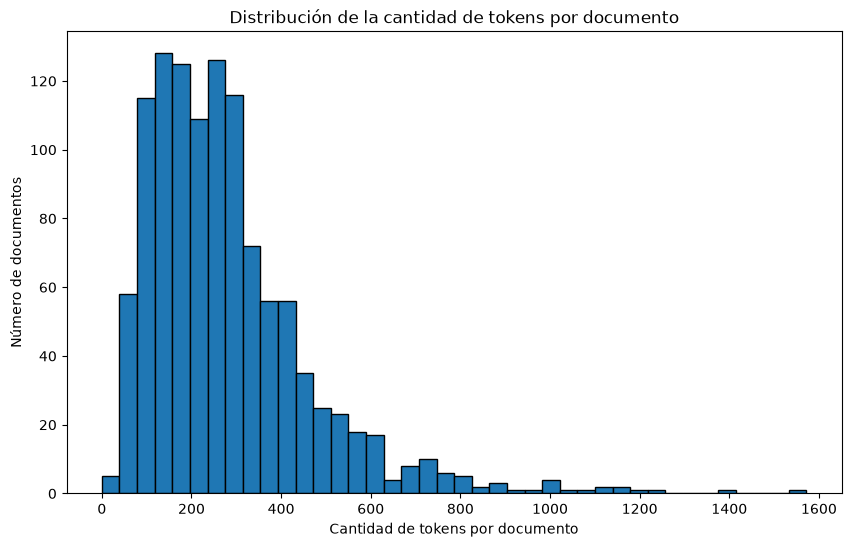

In [29]:
#celda 11
total_df['n_tokens_doc'] = total_df['tok'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(total_df['n_tokens_doc'], bins=40, edgecolor='black')
plt.xlabel('Cantidad de tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de la cantidad de tokens por documento')
plt.show()

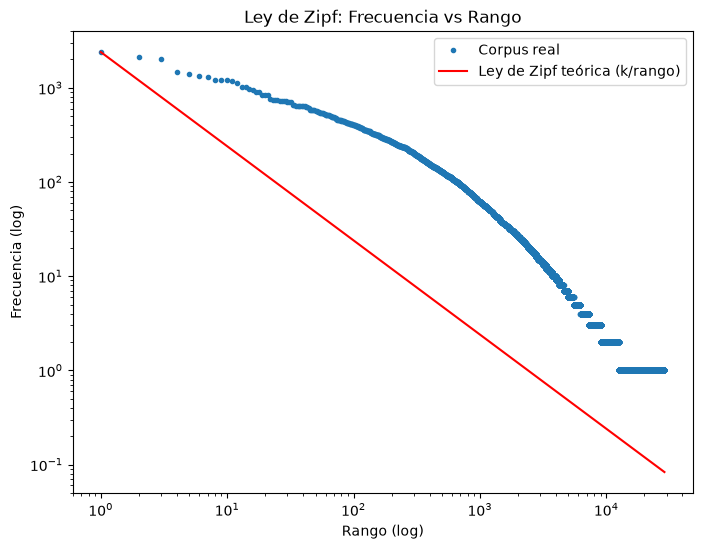

In [30]:
#celda 12
import numpy as np

frecs_ordenadas = sorted(frecuencias.values(), reverse=True)
rangos = np.arange(1, len(frecs_ordenadas) + 1)

k = frecs_ordenadas[0]
zipf_teorico = k / rangos

plt.figure(figsize=(8, 6))
plt.loglog(rangos, frecs_ordenadas, marker='.', linestyle='none', label='Corpus real')
plt.loglog(rangos, zipf_teorico, color='red', label='Ley de Zipf teórica (k/rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.title('Ley de Zipf: Frecuencia vs Rango')
plt.legend()
plt.show()

In [31]:
#celda 13
categorias_a_comparar = total_df['Type'].unique()[:2]  # cambia por las categorías que prefieras

for cat in categorias_a_comparar:
    subset = total_df[total_df['Type'] == cat]
    tokens_cat = [t for lista in subset['tok'] for t in lista]
    frec_cat = Counter(tokens_cat)
    print(f"\nTop 10 palabras — Categoría: {cat}")
    for palabra, freq in frec_cat.most_common(10):
        print(f"  {palabra}: {freq}")


Top 10 palabras — Categoría: Otra
  banco: 386
  bbva: 332
  millón: 275
  financiero: 217
  año: 206
  entidad: 195
  poder: 164
  crédito: 157
  cliente: 142
  tasa: 139

Top 10 palabras — Categoría: Regulaciones
  poder: 275
  decir: 233
  regulación: 230
  empresa: 220
  país: 214
  mercado: 185
  servicio: 173
  hacer: 171
  año: 170
  nuevo: 168


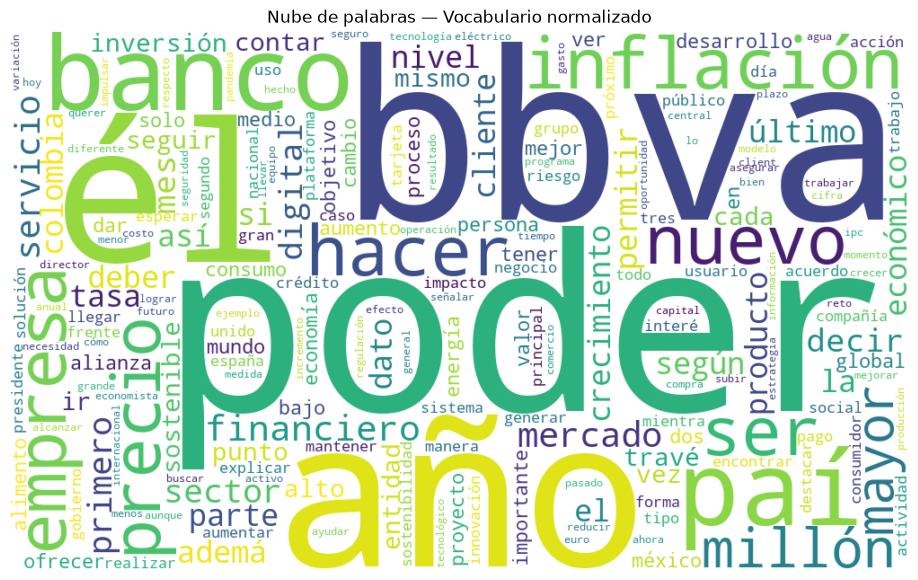

In [32]:
#celda 14
from wordcloud import WordCloud

texto_normalizado = ' '.join(todos_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_normalizado)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Vocabulario normalizado')
plt.show()

# Laboratorio 2: Representaciones de texto

In [33]:
#celda 15
total_df['texto_normalizado'] = total_df['tok'].apply(lambda toks: ' '.join(toks))
total_df['texto_normalizado'].head()

0    foro banca articulador empresarial desarrollo ...
1    regulador valor chino decir domingo buscar coo...
2    industria históricamente masculino aviación vi...
3    dato marzo ipc interanual encadenar decimoquin...
4    ayer cartagena dar inicio versión número 56 co...
Name: texto_normalizado, dtype: str

In [34]:
#celda 16
from sklearn.feature_extraction.text import CountVectorizer

vectorizador_bow = CountVectorizer()
matriz_bow = vectorizador_bow.fit_transform(total_df['texto_normalizado'])

print(f"Shape de la matriz BoW: {matriz_bow.shape}")
print(f"Número de documentos: {matriz_bow.shape[0]}")
print(f"Tamaño del vocabulario: {matriz_bow.shape[1]}")

Shape de la matriz BoW: (1138, 23409)
Número de documentos: 1138
Tamaño del vocabulario: 23409


**¿Qué se pierde y qué se gana con Bag of Words?**

Se pierde el orden de las palabras, la gramática y el contexto. Por ejemplo si hay una oracion o término y se le quita una palabra clave como un "NO", BoW no distingue negaciones ni la posición de las palabras dentro de la oración. 

Lo que se gana es que se vuelve más eficiente ya que es rápido de calcular, fácil de entender, y es util para tareas como clasificación de texto, porque muchas veces con solo saber qué palabras aparecen sin importar el orden y con eso ya alcanza para distinguir de qué tema habla un documento.

In [35]:
#celda 17
total_celdas = matriz_bow.shape[0] * matriz_bow.shape[1]
celdas_no_cero = matriz_bow.nnz 
sparsity = (1 - celdas_no_cero / total_celdas) * 100

print(f"Total de celdas: {total_celdas}")
print(f"Celdas distintas de cero: {celdas_no_cero}")
print(f"Dispersión (sparsity): {sparsity:.2f}%")

Total de celdas: 26639442
Celdas distintas de cero: 221591
Dispersión (sparsity): 99.17%


Vocabulario de 100 palabras: 68.96% de dispersión
Vocabulario de 500 palabras: 83.46% de dispersión
Vocabulario de 1000 palabras: 88.78% de dispersión
Vocabulario de 5000 palabras: 96.64% de dispersión


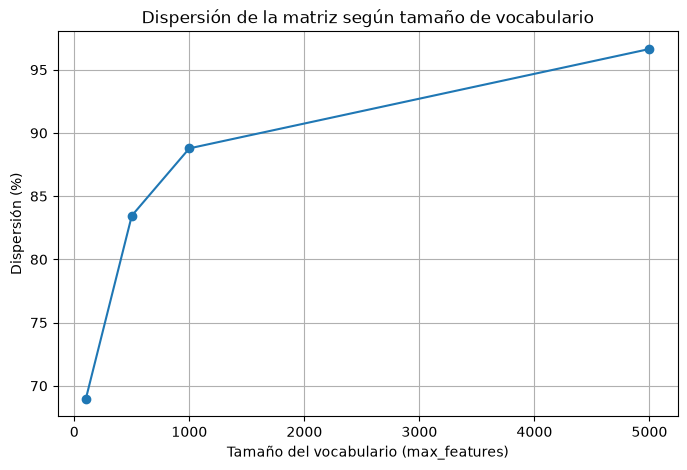

In [36]:
#celda 18
tamaños_vocabulario = [100, 500, 1000, 5000]
dispersiones = []

for tamaño in tamaños_vocabulario:
    vectorizador_prueba = CountVectorizer(max_features=tamaño)
    matriz_prueba = vectorizador_prueba.fit_transform(total_df['texto_normalizado'])
    total = matriz_prueba.shape[0] * matriz_prueba.shape[1]
    no_cero = matriz_prueba.nnz
    disp = (1 - no_cero / total) * 100
    dispersiones.append(disp)
    print(f"Vocabulario de {tamaño} palabras: {disp:.2f}% de dispersión")

plt.figure(figsize=(8, 5))
plt.plot(tamaños_vocabulario, dispersiones, marker='o')
plt.xlabel('Tamaño del vocabulario (max_features)')
plt.ylabel('Dispersión (%)')
plt.title('Dispersión de la matriz según tamaño de vocabulario')
plt.grid(True)
plt.show()

**¿por qué crece la dispersión al aumentar el vocabulario? ¿Qué
implicaciones tiene esto en el costo de almacenamiento y de cómputo?** 


Porque cada documento sigue teniendo mas o menos la misma cantidad de palabras, pero el espacio de columnas disponibles si crece. Entonces si un documento usa 150 palabras distintas y el vocabulario total es de 500, ese documento llena mucho mas el espacio de las columnas. Esto tiene implicaciones directas en almacenamiento, ya que guardar todos esos ceros de forma literal desperdicia un montón la memoria, y hacer cálculos  sobre una matriz gigante es mas exigente para la computadora.


**¿Qué es una matriz dispersa (sparse matrix)?**

Es una estructura de datos especial que, en lugar de guardar todos los números de la matriz (incluyendo los millones de ceros), solo guarda las posiciones y valores de las celdas que NO son cero. 

In [37]:
#celda 19
vectorizador_unigramas = CountVectorizer(ngram_range=(1, 1))
matriz_unigramas = vectorizador_unigramas.fit_transform(total_df['texto_normalizado'])

vectorizador_bigramas = CountVectorizer(ngram_range=(2, 2))
matriz_bigramas = vectorizador_bigramas.fit_transform(total_df['texto_normalizado'])

print(f"Vocabulario con unigramas: {matriz_unigramas.shape[1]} términos")
print(f"Vocabulario con bigramas: {matriz_bigramas.shape[1]} términos")

Vocabulario con unigramas: 23409 términos
Vocabulario con bigramas: 227577 términos


In [38]:
#celda 20
frecuencia_total_bigramas = matriz_bigramas.sum(axis=0)
vocabulario_bigramas = vectorizador_bigramas.get_feature_names_out()

lista_frecuencias_bigramas = [(vocabulario_bigramas[i], frecuencia_total_bigramas[0, i]) for i in range(len(vocabulario_bigramas))]
bigramas_ordenados = sorted(lista_frecuencias_bigramas, key=lambda x: x[1], reverse=True)

top_bigramas = pd.DataFrame(bigramas_ordenados[:15], columns=['bigrama', 'frecuencia'])
top_bigramas

,bigrama,frecuencia
0,banco central,219
1,poder ser,201
2,bbva research,200
3,tasa interés,189
4,cada vez,184
5,entidad financiero,160
6,cambio climático,157
7,punto básico,139
8,año pasado,136
9,bbva méxico,134


**¿Los bigramas aportan información que los unigramas no capturan?**

Sí, varios de los bigramas son términos que si separamos las palabras y las leemos así individualmente, el término deja de tener sentido. Por ejemplo, banco central, tasa interés, cambio climático y entre otros, son términos económicos que si los separás en dos palabras sueltas se pierde esa unidad de significado.

**Ventajas y costo de los bigramas/trigramas frente a unigramas:**

Una ventaja puede ser que dan un poco de contexto y orden local, entonces permite distinguir frases con significado propio que como palabras sueltas no significa lo mismo. 
Por otro lado, una desventaja es que el vocabulario es demasiado grande, es decir, pasamos de 23,409 a 227,577 términos. Esto también significa que la matriz de bigramas va a ser miuchisimo más dispersa que la de unigramas.

In [39]:
#celda 21
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador_tfidf = TfidfVectorizer()
matriz_tfidf = vectorizador_tfidf.fit_transform(total_df['texto_normalizado'])
vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()

print(f"Shape de la matriz TF-IDF: {matriz_tfidf.shape}")

Shape de la matriz TF-IDF: (1138, 23409)


In [40]:
#celda 22
import numpy as np

categorias_unicas = total_df['Type'].unique()[:3]
indices_ejemplo = [total_df[total_df['Type'] == cat].index[0] for cat in categorias_unicas]

for idx in indices_ejemplo:
    categoria = total_df.loc[idx, 'Type']
    vector_tfidf_doc = matriz_tfidf[idx].toarray().flatten()
    indices_top_palabras = vector_tfidf_doc.argsort()[::-1][:10]
    
    print(f"\nDocumento índice {idx} — Categoría: {categoria}")
    for i in indices_top_palabras:
        if vector_tfidf_doc[i] > 0:
            print(f"  {vocabulario_tfidf[i]}: {vector_tfidf_doc[i]:.4f}")


Documento índice 0 — Categoría: Otra
  negocio: 0.2972
  garcía: 0.2377
  sostenibilidad: 0.2019
  físico: 0.1837
  sostenible: 0.1829
  prioridad: 0.1718
  imaginamos: 0.1696
  compitar: 0.1536
  articulador: 0.1536
  acá: 0.1442

Documento índice 1 — Categoría: Regulaciones
  chino: 0.5700
  cotizar: 0.2364
  extranjero: 0.2334
  sec: 0.2218
  csrc: 0.1739
  denegar: 0.1739
  empresa: 0.1562
  regulador: 0.1465
  estadounidense: 0.1290
  decir: 0.1188

Documento índice 2 — Categoría: Alianzas
  viva: 0.3193
  aerolínea: 0.2467
  aerobus: 0.1968
  us50: 0.1782
  aviación: 0.1632
  low: 0.1488
  cost: 0.1428
  avión: 0.1379
  pasajero: 0.1365
  vivo: 0.1338


In [41]:
#celda 23
for idx in indices_ejemplo:
    categoria = total_df.loc[idx, 'Type']
    tokens_doc = total_df.loc[idx, 'tok']
    conteo_doc = Counter(tokens_doc)
    print(f"\nDocumento índice {idx} — Categoría: {categoria} (top 10 por conteo simple)")
    for palabra, freq in conteo_doc.most_common(10):
        print(f"  {palabra}: {freq}")


Documento índice 0 — Categoría: Otra (top 10 por conteo simple)
  negocio: 5
  sostenible: 3
  sostenibilidad: 3
  desarrollo: 2
  garcía: 2
  importante: 2
  poder: 2
  mayor: 2
  tener: 2
  reto: 2

Documento índice 1 — Categoría: Regulaciones (top 10 por conteo simple)
  chino: 12
  empresa: 7
  decir: 5
  valor: 4
  deber: 4
  cotizar: 4
  regulador: 3
  estadounidense: 3
  extranjero: 3
  dicho: 3

Documento índice 2 — Categoría: Alianzas (top 10 por conteo simple)
  año: 4
  trabajar: 3
  bajo: 3
  aerolínea: 3
  modelo: 3
  industria: 2
  aviación: 2
  vivo: 2
  avión: 2
  llegar: 2


**¿Qué valor tienen las palabras top de TF-IDF y qué refleja su puntaje?**

Son las que mejor distinguen a cada documento del resto del corpus. Por ejemplo, en el documento de categoría Alianzas, el top de TF-IDF trae viva, aerobus, us50, low, cost. Lo cual son términos específicos de esa noticia en específico. Eso refleja que el puntaje de TF-IDF no solo mide qué tanto se repite una palabra en el documento, sino qué tan específica es esa palabra comparada con el resto del corpus.

**¿Coinciden las palabras de TF-IDF con las de conteo simple? ¿Por qué?**

Solo algunas coinciden, ya que en el documento de Otra, por conteo simple aparecen poder, importante, mayor, tener, que son mas comunes...
y estas se repiten en casi todo el corpus, pero en TF-IDF esas palabras ni siquiera entran al top 10, porque al ser tan comunes en todo el corpus su IDF está bastante bajo.

**¿Por qué TF-IDF penaliza palabras comunes y favorece palabras raras pero repetidas?**

Porque el objetivo de TF-IDF es medir qué tan única es una palabra para un documento. Entonces si una palabra aparece en casi todos los documentos del corpus, no sirve para diferenciar un documento de otro, entonces el IDF le baja el puntaje aunque el TF sea alto.

In [42]:
#celda 24
from sklearn.metrics.pairwise import cosine_similarity

matriz_similitud = cosine_similarity(matriz_tfidf)

doc_referencia = 0
categoria_referencia = total_df.loc[doc_referencia, 'Type']

similitudes_referencia = matriz_similitud[doc_referencia]
indices_mas_similares = similitudes_referencia.argsort()[::-1][1:6]

print(f"Documento de referencia: índice {doc_referencia}, categoría: {categoria_referencia}")
print("\nLos 5 documentos más similares:")
for idx in indices_mas_similares:
    print(f"  Índice {idx} — Categoría: {total_df.loc[idx, 'Type']} — Similitud: {similitudes_referencia[idx]:.4f}")

Documento de referencia: índice 0, categoría: Otra

Los 5 documentos más similares:
  Índice 545 — Categoría: Otra — Similitud: 0.3181
  Índice 1027 — Categoría: Sostenibilidad — Similitud: 0.2384
  Índice 1008 — Categoría: Otra — Similitud: 0.2202
  Índice 547 — Categoría: Sostenibilidad — Similitud: 0.2191
  Índice 859 — Categoría: Sostenibilidad — Similitud: 0.2150


In [43]:
#celda 25
similitudes_misma_cat = []
similitudes_distinta_cat = []

n_docs = len(total_df)
for i in range(n_docs):
    for j in range(i + 1, n_docs):
        sim = matriz_similitud[i, j]
        if total_df.loc[i, 'Type'] == total_df.loc[j, 'Type']:
            similitudes_misma_cat.append(sim)
        else:
            similitudes_distinta_cat.append(sim)

print(f"Similitud promedio entre documentos de la MISMA categoría: {np.mean(similitudes_misma_cat):.4f}")
print(f"Similitud promedio entre documentos de DISTINTA categoría: {np.mean(similitudes_distinta_cat):.4f}")

Similitud promedio entre documentos de la MISMA categoría: 0.0749
Similitud promedio entre documentos de DISTINTA categoría: 0.0401


**¿Coinciden las categorías de los 5 documentos más similares con la del documento de referencia?**

Algunas si cionciden, es decir, el documento de referencia es de categoría "Otra", y de los 5 docs más similares, 2 también son "Otra" y 3 son Sostenibilidad. ENtonces si cioncide pero no en los 5. Lo que sucede, es que tampoco está agarrando documentos al azar, las categorías que salieron más parecidas, entonces probablemente comparten bastante vocabulario.

**¿Por qué se usa similitud coseno en vez de distancia euclidiana para comparar documentos de distinta longitud?**

Porque la distancia euclidiana mide la diferencia en magnitud entre los vectores, y un documento más largo, obviamente va a tener mas valores  grandes en el vector TF-IDF. Por ende, eso va a hacer que dos documentos que hablan del mismo tema pero uno es más largo que el otro parezcan lejanos según la distancia euclidiana. Por otro lado, la similitud coseno solo se fija en la dirección del vector, osea qué palabras usa y en qué proporción hay entre ellas, entonces estos documentos que hablan del mismo tema salen similares sin importar que uno sea más largo que el otro.